##Bulid A Basic Chatbot Using LangGraph

In [4]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

In [5]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

In [54]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [11]:
from dotenv import load_dotenv
from groq import Groq
from langchain.chat_models import init_chat_model
import os

load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")
if not groq_api_key or groq_api_key.lower() in {"your_groq_api_key", "your-api-key"}:
    raise RuntimeError(
        "Set a valid GROQ_API_KEY in the .env file before creating the chat model."
    )

groq_client = Groq(api_key=groq_api_key)
available_models = {model.id for model in groq_client.models.list().data}
preferred_models = (
    "llama-3.3-70b-versatile",
    "llama-3.1-8b-instant",
    "openai/gpt-oss-20b",
)
model_name = next(
    (model for model in preferred_models if model in available_models),
    None,
)
if model_name is None:
    raise RuntimeError(
        f"This GROQ_API_KEY cannot access a supported chat model. Available models: "
        f"{sorted(available_models)}"
    )

llm = init_chat_model(
    model_name,
    model_provider="groq",
    api_key=groq_api_key,
)

llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x00000135B078D810>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x00000135B078E350>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [6]:
## Node Functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [7]:
graph_builder=StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)
## Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph=graph_builder.compile()

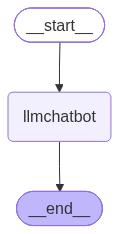

In [59]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [12]:
response = graph.invoke({"messages": [{"role": "user", "content": "Hi"}]})

In [ ]:
response["messages"][-1].content

'Hello! How can I help you today?'

In [13]:
for event in graph.stream({"messages": [{"role": "user", "content": "Hi How are you?"}]}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello! I’m doing great—thanks for asking. How about you? Anything new or exciting happening on your end?


##Chatbot With Tools

In [15]:
import os
from dotenv import load_dotenv
from langchain_tavily import TavilySearch

load_dotenv()
tavily_api_key = os.getenv("TAVILY_API_KEY")
if not tavily_api_key or tavily_api_key.lower() in {"your_tavily_api_key", "your-api-key"}:
    raise RuntimeError(
        "Set a valid TAVILY_API_KEY in the .env file before using web search."
    )

tool = TavilySearch(max_results=2, tavily_api_key=tavily_api_key)
tool.invoke("What is LangGraph?")

{'query': 'What is LangGraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian C